In [1]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/ImageProcessing/Lab3_3/'

Mounted at /content/drive


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

Exercise1: Image enhancement in the spatial domain using a median filter

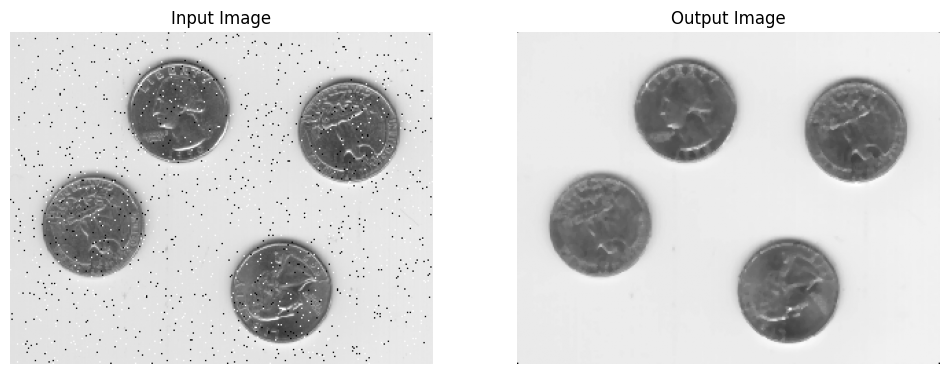

In [ ]:
image1_path = path + "eight_salt_pepper.tif"

image1 = cv2.imread(image1_path,0)

pad = 1

height, width = image1.shape

output = np.zeros_like(image1)

padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=image1.dtype)
padded_image[pad:pad+height, pad:pad+width] = image1


for i in range(height):
    for j in range(width):

          window = padded_image[i:i+3, j:j+3]

          sorted_pixels = np.sort(window,axis=None)

          median = sorted_pixels[4]

          output[i, j] = median

plt.figure(figsize=(12,12))

plt.subplot(1,2,1)
plt.axis("off")
plt.title("Input Image")
plt.imshow(image1,cmap="gray")

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Output Image")
plt.imshow(output,cmap='gray')

plt.show()

Exercise2: Image enhancement in the spatial domain using an average filter

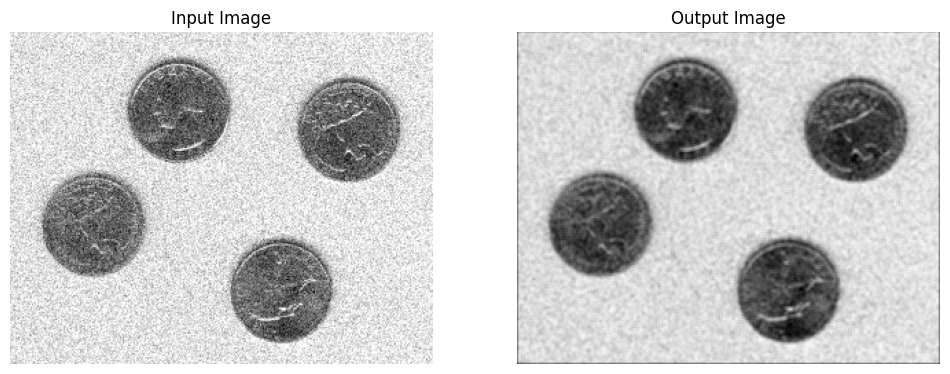

In [22]:
image2_path = path + "eight_gaussian.tif"
image2 = cv2.imread(image2_path,0)

output = np.zeros([image2.shape[0],image2.shape[1]])

pad = 1

height, width = image2.shape

padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=image2.dtype)
padded_image[pad:pad+height, pad:pad+width] = image2

mask = np.ones((3, 3), dtype=np.float32) / 9.0

for i in range(height):
    for j in range(width):
            window = padded_image[i:i+3, j:j+3]
            output[i, j] = np.sum(window*mask)

output = np.round(output).astype(np.uint8)


plt.figure(figsize=(12,12))

plt.subplot(1,2,1)
plt.axis("off")
plt.title("Input Image")
plt.imshow(image2,cmap="gray")

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Output Image")
plt.imshow(output,cmap="gray")

plt.show()

In [10]:
A = np.array([[18, 20, 12, 120, 255],
              [9, 84, 26, 36, 255],
              [12, 150, 6, 78, 99],
              [140, 18, 16, 25, 12],
              [220, 254, 32, 64, 41]], dtype=np.uint8)

pad = 1

height, width = A.shape

mask = np.ones((3, 3), dtype=np.float32) / 9.0

output = np.zeros_like(A, dtype=np.uint8)

padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=A.dtype)
padded_image[pad:pad+height, pad:pad+width] = A

for i in range(height):
    for j in range(width):
            window = np.sum(padded_image[i:i+3, j:j+3]*mask)
            output[i, j] = np.clip(window, 0, 255)

print(output)


[[14 18 33 78 74]
 [32 37 59 98 93]
 [45 51 48 61 56]
 [88 94 71 41 35]
 [70 75 45 21 15]]


Exercise3: Image enhancement in spatial domain using first-order derivative filter (Gradient mask filter)

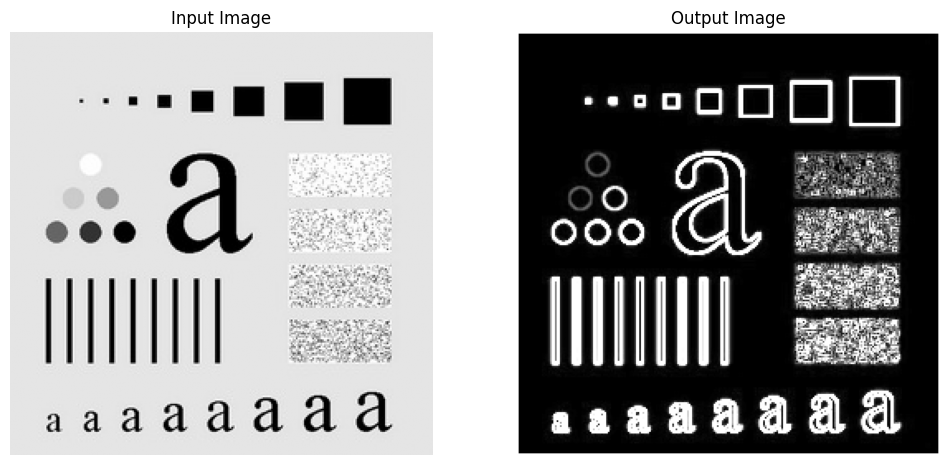

In [21]:
image3_path = path + "aaa256.jpg"

image3 = cv2.imread(image3_path,0)

pad = 1

height, width  =  image3.shape

padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=image3.dtype)
padded_image[pad:pad+height, pad:pad+width] = image3

prewitt_x = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]], dtype=np.float32)

prewitt_y = np.array([[-1, -1, -1],
                    [ 0,  0,  0],
                    [ 1,  1,  1]], dtype=np.float32)

grad_sum = np.zeros([image3.shape[0],image3.shape[1]])

for i in range(height):
    for j in range(width):
        gx = np.sum(padded_image[i:i+3, j:j+3]*prewitt_x)
        gy = np.sum(padded_image[i:i+3, j:j+3]*prewitt_y)

        grad_sum[i, j] = np.abs(gx) + np.abs(gy)

grad_sum = np.clip(grad_sum, 0, 255)

plt.figure(figsize=(12,12))

plt.subplot(1,2,1)
plt.axis("off")
plt.title("Input Image")
plt.imshow(image3,cmap="gray")

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Output Image")
plt.imshow(grad_sum,cmap="gray")

plt.show()

Exercise4: Image enhancement in spatial domain using second-order derivative filter (simplified Laplacian
filter)

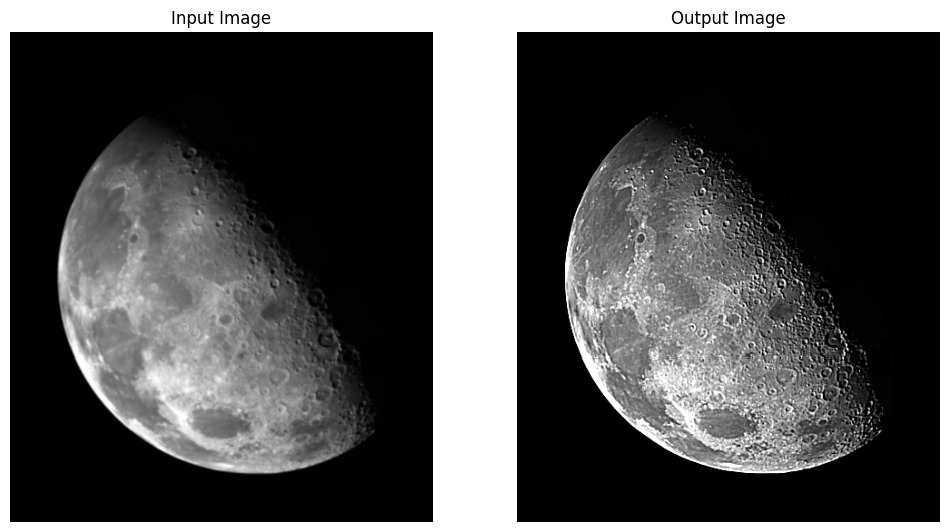

In [8]:
image4_path = path + "blurry_moon.tif"

image4 = cv2.imread(image4_path,0)

pad = 1

laplacian_filter = np.array([[-1, -1, -1],
                             [-1, 9, -1],
                             [-1, -1, -1]], dtype=np.float32)

height, width = image4.shape
sharpened_image = np.zeros_like(image4, dtype=np.float32)

padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=image4.dtype)
padded_image[pad:pad+height, pad:pad+width] = image4

output =  np.zeros_like(image4, dtype=np.uint8)

for i in range(height):
    for j in range(width):
        window = np.sum(padded_image[i:i+3, j:j+3]*laplacian_filter)
        output[i, j] = np.clip(window, 0, 255)

plt.figure(figsize=(12, 12))

plt.subplot(1,2,1)
plt.axis("off")
plt.title("Input Image")
plt.imshow(image4,cmap="gray")

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Output Image")
plt.imshow(output,cmap="gray")

plt.show()